In [1]:
import argparse
import csv
import matplotlib.pyplot as plt
import torch as ch
import sys

import IPython
import IPython.display as ipd
import numpy as np
sys.path.append('../.')
from auditorytexture import default_params
from auditorytexture import helpers
from auditorytexture import statistics_sets
from auditorytexture import texture_datasets

sys.path.append('../stationarityscreen/')
import stationarity_score
from auditorytexture import audio_input_transforms as at
ch.backends.cudnn.benchmark = True

from auditorytexture import texture_datasets
audioset_screen_dataset = texture_datasets.NoSpeechOrMusicOrSourcelessAudioSet(transform=None, 
                                                                               return_meta_with_item=True)

# sys.path.append('../../../texture_prior/params/')
# import model_params

In [2]:
!nvidia-smi

Tue Jun 20 12:35:58 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 515.86.01    Driver Version: 515.86.01    CUDA Version: 11.7     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA A100 80G...  On   | 00000000:03:00.0 Off |                    0 |
| N/A   43C    P0    54W / 300W |      0MiB / 81920MiB |      0%      Default |
|                               |                      |             Disabled |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [3]:
def update_param_dicts(coch_params, octmod_params, mod_params, duration, audio_sr):
    # duration is in seconds
    signal_length = int(duration * audio_sr)
    coch_signal_length = int(signal_length * coch_params['rep_kwargs']['env_sr'] / audio_sr)
    coch_params['rep_kwargs']['signal_size'] = signal_length
    mod_params['coch_signal_length'] = coch_signal_length
    octmod_params['coch_signal_length'] = coch_signal_length
    return coch_params, octmod_params, mod_params

def flatten_batch_list(batch_list):
    return [item for sublist in batch_list for item in sublist]


def run_all_sounds_overlapped_stationarity_screen_mcdsim2011(sound_list_csv_path, 
                                                  normalization_dict=stationarity_score.NORM_DEFAULT_PATH,
                                                  window_std_norm_dict=stationarity_score.WINDOW_STD_NORM_DEFAULT_PATH,
                                                  dataset_subset=None,
                                                  batch_size=2,
                                                  num_workers=0,
                                                  window_sizes_secs=[0.125, 0.250, 0.500, 1],
                                                  base_filepath=None,
                                                  frame_step_secs=None
                                                  ):
    
    coch_params = default_params.cochleagram_matlab_stable_grad_10s
    octmod_params = default_params.octmodparams_matlab_10s
    mod_params = default_params.constqmodparams_matlab_10s
    statistics_dict = statistics_sets.STAT_SET_FULL_MCDERMOTTSIMONCELLI
    
    coch_params, octmod_params, mod_params = update_param_dicts(coch_params, 
                                                                octmod_params, 
                                                                mod_params, 
                                                                2, 
                                                                20000)

    stationarity_func = stationarity_score.StationarityScore(coch_params, 
                                          mod_params, 
                                          octmod_params,
                                          statistics_dict,
                                          window_sizes_secs=window_sizes_secs,
                                          window_overlap=None).cuda()
    
    rms_func = at.RMSNormalize()

    transforms = ch.nn.Sequential(at.AudioToTensor(), at.CenterCrop(10, coch_params['rep_kwargs']['sr']),
                                  at.RMSNormalize(), at.UnsqueezeAudio(dim=0))

    if dataset_subset is not None:
        audioset_screen_dataset = ch.utils.data.Subset(texture_datasets.EvalNoSpeechOrMusicOrSourcelessAudioSet(transform=transforms, return_meta_with_item=True),dataset_subset)
    else:
        audioset_screen_dataset = texture_datasets.EvalNoSpeechOrMusicOrSourcelessAudioSet(transform=transforms, return_meta_with_item=True)

    audioset_screen_dataset = ch.utils.data.DataLoader(audioset_screen_dataset,
                                                       batch_size=1, shuffle=True,
                                                       num_workers=num_workers, pin_memory=True)
    
    #return audioset_screen_dataset
    import os
    from tqdm import tqdm
    if not os.path.exists(normalization_dict):
        _, _ = stationarity_func._measure_full_texture_normalization_values(audioset_screen_dataset, save_values_name=normalization_dict)
    if not os.path.exists(window_std_norm_dict):
        _, _ = stationarity_func_measure_windowed_stats_normalization_values(audioset_screen_dataset, save_values_name=window_std_norm_dict)

    
    # changed in loop
    sr = None
    fs = None
    framed_idx = None
    
    top_k_most_stationary = 10
    length_of_clip = 10 #in seconds
    
    all_batch_stationarity = []
    all_batch_labels = []
    all_batch_wav_path = []
    all_batch_short_filepath = []
    all_batch_onset_times = []
    all_batch_rankings    = []
    
    # How are we saving the stationarity scores? Make a new cvs with the paths and the scores and the labels?
    for i, (input_audio, labels, wav_path, label_str, short_filepath) in enumerate(tqdm(audioset_screen_dataset)):
        if sr is None:
            sr = input_audio.shape[-1] / length_of_clip
            idx = ch.arange(0, input_audio.shape[-1])
            fs = helpers.FrameSignal(2, sr, frame_dim=-1, frame_step_secs=frame_step_secs)
            framed_idx = fs(idx)
            
        input_audio = input_audio[0]
        
        framed_audio = fs(input_audio)
        
        # rms normalizing all frames
        framed_audio = ch.stack([rms_func(x[0]) for x in framed_audio]).unsqueeze(1)
        #print(ch.isnan(framed_audio).any())
        
        batch_s = stationarity_func(framed_audio.cuda())
        
        # find the time onsets (in terms of sample numbers) corresponding to the
        # top k most stationary segments, and then convert those sample numbers
        # to times (in secs) by dividing by the sampling rate
        top_k_indices = ch.argsort(batch_s)[:top_k_most_stationary]
        top_k_scores  = batch_s[top_k_indices]
        
        # times at which they occur
        times = fs(idx)[top_k_indices][:, 0] / sr
        
        #print(times)
        
        #TODO: add information from the top k sounds that passed 
        # see code below
        # Sending this back to the CPU adds a little bit of overhead, but this is only run once per dataset. 
        all_batch_stationarity.append(top_k_scores)
        all_batch_labels.append([label_str]*top_k_most_stationary)
        all_batch_wav_path.append([wav_path]*top_k_most_stationary)
        all_batch_short_filepath.append([short_filepath]*top_k_most_stationary)
        all_batch_onset_times.append(times)
        all_batch_rankings.append(np.arange(1,top_k_most_stationary+1))
        
        return (batch_s, fs(input_audio),
            input_audio, labels, wav_path, label_str, short_filepath)

        if i > 1:
            break
            
    all_batch_stationarity = flatten_batch_list(all_batch_stationarity)
    all_batch_stationarity = [x.cpu().item() for x in all_batch_stationarity]
    
    # these need to be flattened twice (many nested lists)
    all_batch_labels = flatten_batch_list(all_batch_labels)
    all_batch_labels = flatten_batch_list(all_batch_labels)

    all_batch_wav_path = flatten_batch_list(all_batch_wav_path)
    all_batch_wav_path = flatten_batch_list(all_batch_wav_path)

    all_batch_short_filepath = flatten_batch_list(all_batch_short_filepath)
    all_batch_short_filepath = flatten_batch_list(all_batch_short_filepath)
    
    all_batch_onset_times = flatten_batch_list(all_batch_onset_times)
    all_batch_onset_times = [x.cpu().item() for x in all_batch_onset_times]
    
    all_batch_rankings = flatten_batch_list(all_batch_rankings)
    
    # If we included a "base_filepath" then remove this from the saved csv. 
    # This makes the csv smaller for uploading. 
    if base_filepath is not None:
        all_batch_wav_path = [w.split(base_filepath)[-1] for w in all_batch_wav_path]
    
    
#     # Now save a CSV with the stationarity values included. 
#     with open(sound_list_csv_path, 'w') as f:
#         writer = csv.writer(f)
#         writer.writerow(['filepath', 'short_filepath', 'labels', 'stationarity_score', 'within_sound_ranking', 'onset_time'])
#         for s_info in zip(all_batch_wav_path, all_batch_short_filepath, all_batch_labels, all_batch_stationarity, all_batch_rankings, all_batch_onset_times):
#             writer.writerow([s_info[0], s_info[1], s_info[2], s_info[3], s_info[4], s_info[5]])
            


In [4]:
def get_all_sounds_stationarity_score_cochleagram_matlab_10s(sound_list_csv_path, 
                                                             batch_size=32, 
                                                             num_workers=40, 
                                                             frame_step_secs=None):
    return run_all_sounds_overlapped_stationarity_screen_mcdsim2011(sound_list_csv_path,
                                                  dataset_subset=None,
                                                  batch_size=batch_size,
                                                  num_workers=num_workers,
                                                  base_filepath='/om2/data/public/audioset/wavs/eval_segments_downloads/',
                                                  frame_step_secs=frame_step_secs
                                                  )

In [5]:
frame_step_secs = 0.5
batch_s, fs_input_audio, input_audio, labels, wav_path, label_str, short_filepath = get_all_sounds_stationarity_score_cochleagram_matlab_10s('../assets/TEST_OVERLAPPED_eval_sound_list_with_stationarity_score_no_speech_no_music_audioset_matlab_coch_rms0p02.csv',
                                                              frame_step_secs=frame_step_secs)

  0%|          | 0/6612 [00:07<?, ?it/s]


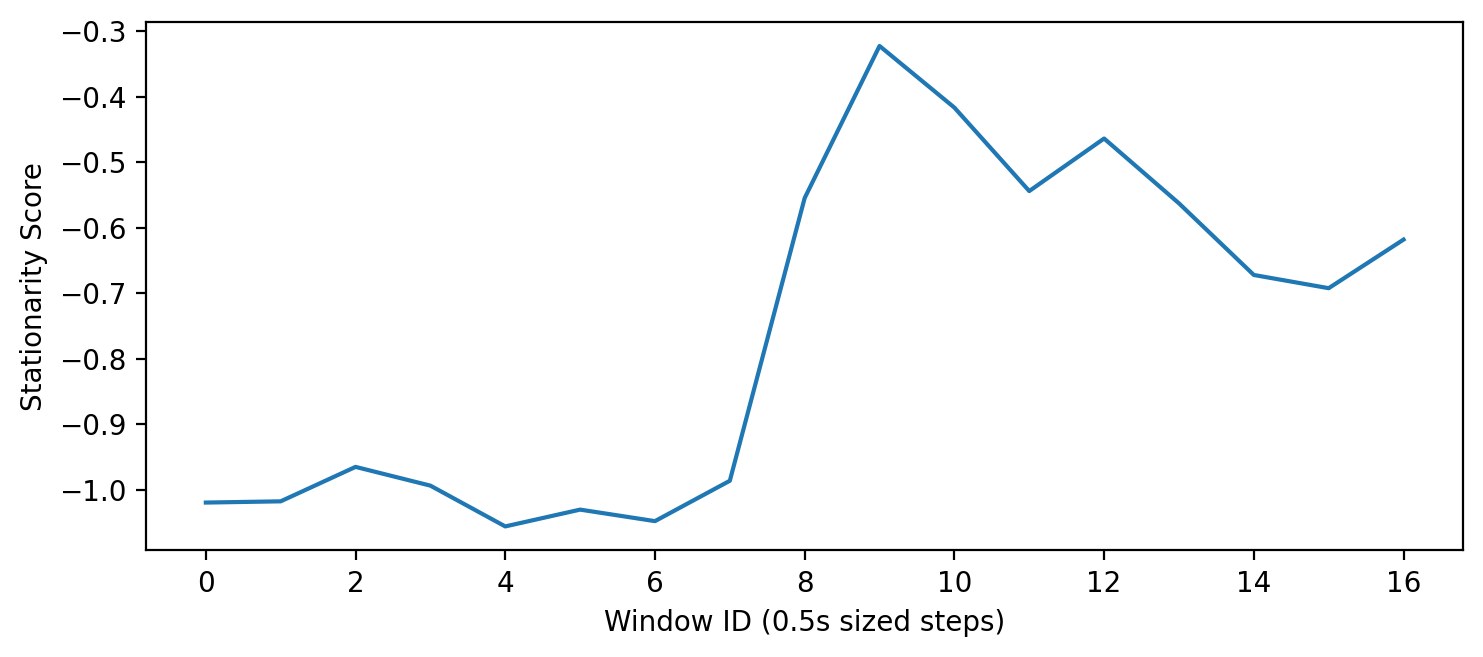

In [6]:
plt.plot(batch_s.cpu())
plt.xlabel("Window ID ({}s sized steps)".format(frame_step_secs))
plt.ylabel("Stationarity Score")

fig = plt.gcf()
fig.set_size_inches(8.5, 3.5)
fig.set_dpi(200)

In [7]:
ordered_scores_idx = ch.argsort(batch_s).cpu()

# Full Sound

In [8]:
print(audioset_screen_dataset.mid_to_human_readable[label_str[0].split(",")[0]])
ipd.Audio(input_audio, rate=20000)

Cacophony


# 2s segments ranked by stationarity

In [9]:
for sound_idx in ordered_scores_idx:
    print("At time {} s".format(sound_idx*frame_step_secs))
    print("Stationarity:", batch_s[sound_idx].cpu().item())
    audio_path = wav_path
    IPython.display.display(IPython.display.Audio(fs_input_audio[sound_idx], rate=20000))
    print("=========")
#ipd.Audio(fs_input_audio[ordered_scores_idx[0]], rate=20000)

At time 2.0 s
Stationarity: -1.0558438301086426


At time 3.0 s
Stationarity: -1.047784447669983


At time 2.5 s
Stationarity: -1.030202865600586


At time 0.0 s
Stationarity: -1.019446849822998


At time 0.5 s
Stationarity: -1.0175694227218628


...

At time 4.0 s
Stationarity: -0.5548137426376343


At time 5.5 s
Stationarity: -0.5442100167274475


At time 6.0 s
Stationarity: -0.46402159333229065


At time 5.0 s
Stationarity: -0.41688433289527893


At time 4.5 s
Stationarity: -0.32284075021743774
